# Klasifikasi Kucing vs Anjing menggunakan Lightweight CNN

Notebook ini melatih model CNN kustom yang sangat ringan (lightweight) dan efisien secara komputasi untuk mengklasifikasikan gambar kucing dan anjing. Model ini menyertakan perbaikan penting berikut:
1. **Input Normalization**: Penskalaan nilai piksel ke `[0, 1]` menggunakan layer `Rescaling` agar model dapat berkonvergensi dengan cepat.
2. **Global Average Pooling**: Menggantikan layer `Flatten` untuk memangkas jumlah parameter model di bawah **150.000 parameter** sehingga sangat ringan dan cepat di-training bahkan di CPU.
3. **Evaluasi yang Benar**: Menggunakan threshold `0.5` pada output sigmoid untuk metrik evaluasi yang valid.

## 1. Import Library

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, Sequential, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image

I0000 00:00:1780017579.282374    8846 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780017579.283027    8846 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780017579.335413    8846 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780017580.808297    8846 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## 2. Konfigurasi & Path Dataset

In [2]:
BATCH_SIZE = 32
IMAGE_SIZE = (160, 160)
SEED = 42

base_dir = "../datasets/project2/cnn"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")
valid_dir = os.path.join(base_dir, "valid")

## 3. Memuat Dataset

In [ ]:
print("Loading Train Dataset:")
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    label_mode='int',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

print("\nLoading Validation Dataset:")
valid_ds = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir,
    label_mode='int',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

print("\nLoading Test Dataset:")
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    label_mode='int',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False, # Jangan di-shuffle untuk evaluasi CM/Classification Report yang akurat
    seed=SEED
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nClasses: {class_names}")
print(f"Jumlah Class: {num_classes}")

# Simpan nama kelas untuk digunakan di API Prediksi
with open("cat_and_dog.json", "w") as f:
    json.dump(class_names, f)

Loading Train Dataset:
Found 17498 files belonging to 2 classes.

Loading Validation Dataset:
Found 3752 files belonging to 2 classes.


E0000 00:00:1780017581.736989    8846 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



Loading Test Dataset:
Found 3748 files belonging to 2 classes.

Classes: ['Cat', 'Dog']
Jumlah Class: 2


## 4. Pembersihan Data Gambar Corrupt

In [4]:
folders = [train_dir, valid_dir, test_dir]
print("Memeriksa dan membersihkan gambar corrupt...")
for dataset_path in folders:
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                with Image.open(file_path) as img:
                    img.verify() # verifikasi integritas gambar
            except Exception as e:
                print(f"Menghapus gambar corrupt: {file_path}. Error: {e}")
                os.remove(file_path)
print("Pemeriksaan selesai.")

Memeriksa dan membersihkan gambar corrupt...
Pemeriksaan selesai.


## 5. Menghitung Bobot Kelas

In [5]:
y_train = np.concatenate([y for x, y in train_ds], axis=0)
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights))

print("Bobot kelas untuk menyeimbangkan training:")
for i, name in enumerate(class_names):
    print(f"  {name}: {class_weight_dict[i]:.2f}")

Bobot kelas untuk menyeimbangkan training:
  Cat: 1.00
  Dog: 1.00


## 6. Membangun Model CNN yang Ringan (Lightweight)

In [6]:
# Data Augmentasi Ringan untuk mencegah Overfitting
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
])

# Membangun Arsitektur Model
model = Sequential([
    # Input layer
    layers.Input(shape=IMAGE_SIZE + (3,)),

    # Augmentasi data
    data_augmentation,

    # Penskalaan Piksel dari [0, 255] ke [0, 1] (Sangat Kritis!)
    layers.Rescaling(1./255),

    # Blok Konvolusi 1
    layers.Conv2D(16, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Blok Konvolusi 2
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Blok Konvolusi 3
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Blok Konvolusi 4
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Global Average Pooling (Mengurangi parameter dari 3 Juta ke <150 Ribu!)
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),

    # Fully Connected Layer
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid') # Binary classifier
])

# Compile Model
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 160, 160, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 106,721 (416.88 KB)

 Trainable params: 106,241 (415.00 KB)

 Non-trainable params: 480 (1.88 KB)

## 7. Melatih Model

In [7]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

print("Memulai training model...")
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Memulai training model...
Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 336s 608ms/step - accuracy: 0.6103 - loss: 0.6564 - val_accuracy: 0.5682 - val_loss: 0.6620 - learning_rate: 0.0010
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 379s 604ms/step - accuracy: 0.6626 - loss: 0.6120 - val_accuracy: 0.6103 - val_loss: 0.6386 - learning_rate: 0.0010
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 330s 603ms/step - accuracy: 0.6944 - loss: 0.5832 - val_accuracy: 0.6554 - val_loss: 0.6230 - learning_rate: 0.0010
Epoch 4/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 331s 605ms/step - accuracy: 0.7149 - loss: 0.5572 - val_accuracy: 0.5269 - val_loss: 1.0901 - learning_rate: 0.0010
Epoch 5/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 324s 593ms/step - accuracy: 0.7251 - loss: 0.5433 - val_accuracy: 0.6980 - val_loss: 0.5724 - learning_rate: 0.0010
Epoch 6/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 388s 604ms/step - accuracy: 0.7368 - loss: 0.5270 - val_accuracy: 0.7425 - val_loss: 0.5334 - learning_rate: 0.0010
Epoch 7/15
547/547 ━━━━━━━━━━━━━━━━━━━

## 8. Evaluasi Model pada Test Dataset

118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - accuracy: 0.8159 - loss: 0.4011
Test Loss: 0.4011
Test Accuracy: 81.59%
118/118 ━━━━━━━━━━━━━━━━━━━━ 13s 109ms/step

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

         Cat       0.81      0.83      0.82      1874
         Dog       0.82      0.80      0.81      1874

    accuracy                           0.82      3748
   macro avg       0.82      0.82      0.82      3748
weighted avg       0.82      0.82      0.82      3748



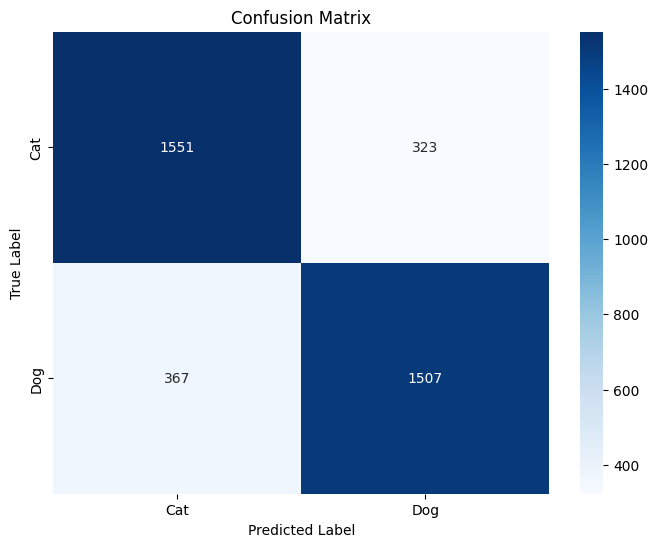

In [8]:
# Evaluasi Loss dan Akurasi
loss, acc = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc*100:.2f}%")

# Prediksi
predictions = model.predict(test_ds)
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = (predictions > 0.5).astype(int).flatten() # Thresholding yang benar untuk binary sigmoid

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 9. Plot Kurva Belajar (Learning Curves)

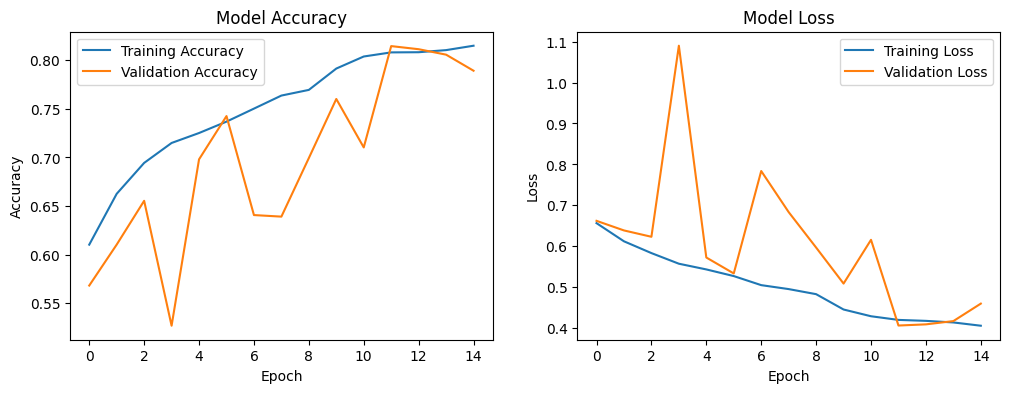

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 10. Menyimpan Model

In [10]:
os.makedirs("../models", exist_ok=True)
model_path = "../models/cat_vs_dog_v2.keras"
model.save(model_path)
print(f"Model berhasil disimpan di: {model_path}")

Model berhasil disimpan di: ../models/cat_vs_dog_v2.keras
